# Por que achar um mínimo de uma função?

## 1️⃣ Conceito de “minimizar uma função”

Minimizar uma função significa encontrar \(x^*\) tal que:

$$
f(x^*) \le f(x) \quad \text{para todo } x
$$

- A função \(f(x)\) mede **quão ruim está a solução**  
- Minimizar significa **tornar essa medida a menor possível**  

---

## 2️⃣ Aplicação em Regressão Linear

No exemplo de regressão linear:

$$
\hat{y} = w x + b
$$

A função de custo (MSE) é:

$$
J(w,b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - (w x_i + b))^2
$$

- \(J(w,b)\) mede **quão distante o modelo está dos dados reais**  
- O **mínimo de \(J\)** corresponde à **melhor aproximação possível dos dados**

---

## 3️⃣ Gradiente e atualização

O gradiente da função de custo:

$$
\nabla J(w,b) =
\begin{pmatrix}
\frac{\partial J}{\partial w} \\
\frac{\partial J}{\partial b}
\end{pmatrix}
=
\begin{pmatrix}
-\frac{2}{n} \sum_{i=1}^{n} x_i (y_i - (w x_i + b)) \\
-\frac{2}{n} \sum_{i=1}^{n} (y_i - (w x_i + b))
\end{pmatrix}
$$

Atualização dos parâmetros (gradiente descendente):

$$
w_{\text{novo}} = w - \eta \frac{\partial J}{\partial w}, \quad
b_{\text{novo}} = b - \eta \frac{\partial J}{\partial b}
$$

---

## 4️⃣ Intuição geométrica

- Imagine \(J(w,b)\) como um **vale**:  
  - Cada ponto \((w,b)\) tem uma altura = valor de \(J\)  
  - O **mínimo** é o **fundo do vale**  
- Descer usando gradiente descendente = **caminhar até o fundo do vale**  
- Para regressão linear, o “vale” é **convexo**, com **único mínimo global**

---

## 5️⃣ Analogias do mundo real

1. **Ajustar uma régua nos dados**  
   - Queremos que a régua passe o mais próximo possível de todos  
   - Minimizar o custo = **encontrar melhor ângulo e altura da régua**

2. **Montanha / vale**  
   - Objetivo: **chegar no ponto mais baixo**  
   - O gradiente indica a direção de descida

3. **Tomando decisões**  
   - \(J(x)\) mede “quanto você gasta”  
   - Minimizar \(J\) = **gastar o mínimo possível**

---

## 6️⃣ Conclusão

> A ideia de achar um mínimo de uma função é **central em otimização e aprendizado de máquina**, porque queremos **melhorar nosso modelo** tornando o erro o menor possível.

- No ML: minimizar **erro de previsão**  
- Em engenharia: minimizar **custo ou desperdício**  
- Em física: minimizar **energia potencial**  

Ou seja, **tudo se resume a encontrar a melhor solução possível** ✅


In [1]:
import random

# dados simples
X = [1, 2, 3, 4]
Y = [2, 4, 6, 8]

# parâmetros iniciais
w = 0.0
b = 0.0
lr = 0.01  # learning rate

# treinamento
for epoch in range(10):
    i = random.randint(0, len(X) - 1)  # escolhe 1 dado (stochastic)
    print(i)
    
    x = X[i]
    y = Y[i]
    
    y_pred = w * x + b
    error = y - y_pred
    
    # gradientes
    dw = -2 * x * error
    db = -2 * error
    
    # atualização
    w = w - lr * dw
    b = b - lr * db

    print(w, b)


2
0.36 0.12
0
0.39039999999999997 0.1504
1
0.5131519999999999 0.21177600000000002
3
0.97200128 0.32648832000000005
0
0.986031488 0.34051852800000004
0
0.99950048768 0.35398752768
1
1.0653809475584 0.3869277576192
0
1.0763347734548478 0.397881583515648
2
1.2187216192220363 0.44534386543804416
3
1.4331031918359411 0.4989392585915204


Matplotlib is building the font cache; this may take a moment.


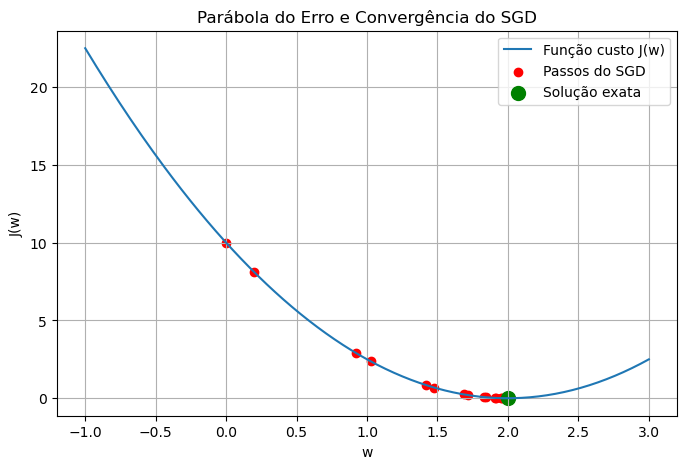

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dados
# -----------------------------
x = np.array([1.0, 2.0])
y = np.array([2.0, 4.0])

# -----------------------------
# Função custo total
# J(w) = 1/2 * sum((wx - y)^2)
# -----------------------------
def cost(w):
    return 0.5 * np.sum((w * x - y) ** 2)

# -----------------------------
# 1) Solução fechada
# -----------------------------
w_closed = np.dot(x, y) / np.dot(x, x)

# -----------------------------
# 2) SGD
# -----------------------------
w = 0.0
eta = 0.1
epochs = 20

w_history = [w]

for epoch in range(epochs):
    for i in range(len(x)):
        y_hat = w * x[i]
        gradient = (y_hat - y[i]) * x[i]
        w = w - eta * gradient
        w_history.append(w)

# -----------------------------
# Criando gráfico
# -----------------------------
w_values = np.linspace(-1, 3, 200)
cost_values = [cost(wi) for wi in w_values]

plt.figure(figsize=(8,5))

# Parábola do erro
plt.plot(w_values, cost_values, label="Função custo J(w)")

# Caminho do SGD
plt.scatter(w_history, [cost(wi) for wi in w_history],
            color="red", label="Passos do SGD")

# Mínimo exato
plt.scatter(w_closed, cost(w_closed),
            color="green", s=100, label="Solução exata")

plt.xlabel("w")
plt.ylabel("J(w)")
plt.title("Parábola do Erro e Convergência do SGD")
plt.legend()
plt.grid(True)

plt.show()


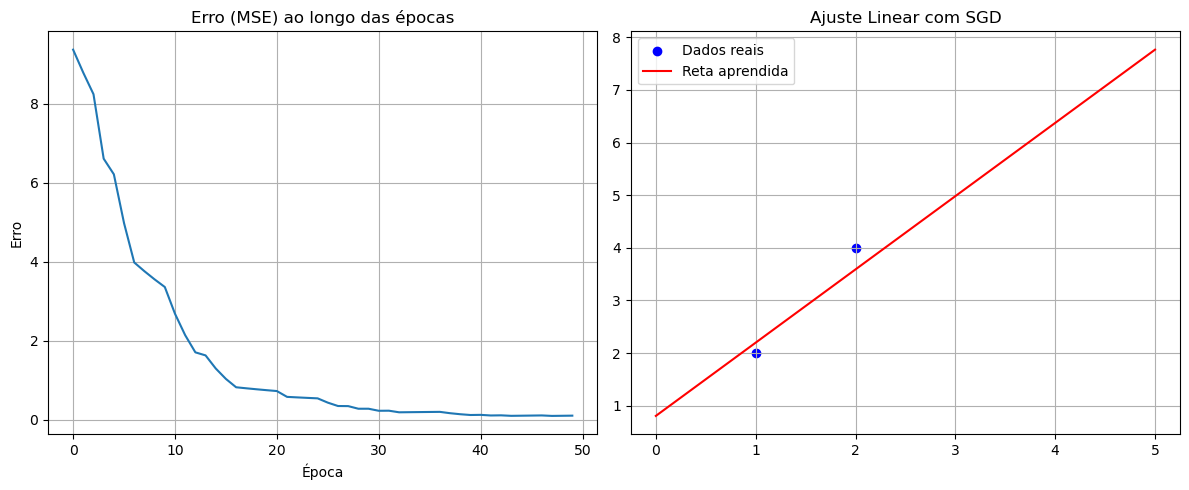

w final: 1.3919258051146286
b final: 0.8068642894782315


In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dados
# -----------------------------
X = [1, 2]
Y = [2, 4]

# -----------------------------
# Parâmetros iniciais
# -----------------------------
w = 0.0
b = 0.0
lr = 0.01
epochs = 50

# Para guardar histórico
w_history = []
b_history = []
loss_history = []

# -----------------------------
# Treinamento (SGD)
# -----------------------------
for epoch in range(epochs):
    i = random.randint(0, len(X) - 1)
    
    x = X[i]
    y = Y[i]
    
    y_pred = w * x + b
    error = y - y_pred
    
    # gradientes
    dw = -2 * x * error
    db = -2 * error
    
    # atualização
    w = w - lr * dw
    b = b - lr * db
    
    # cálculo do erro total (MSE)
    total_loss = np.mean([(w * X[j] + b - Y[j])**2 for j in range(len(X))])
    
    w_history.append(w)
    b_history.append(b)
    loss_history.append(total_loss)

# -----------------------------
# Gráficos
# -----------------------------
plt.figure(figsize=(12,5))

# 1️⃣ Gráfico do erro
plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Erro (MSE) ao longo das épocas")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.grid(True)

# 2️⃣ Ajuste final da reta
plt.subplot(1,2,2)
plt.scatter(X, Y, color="blue", label="Dados reais")

x_line = np.linspace(0, 5, 100)
y_line = w * x_line + b

plt.plot(x_line, y_line, color="red", label="Reta aprendida")
plt.title("Ajuste Linear com SGD")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("w final:", w)
print("b final:", b)


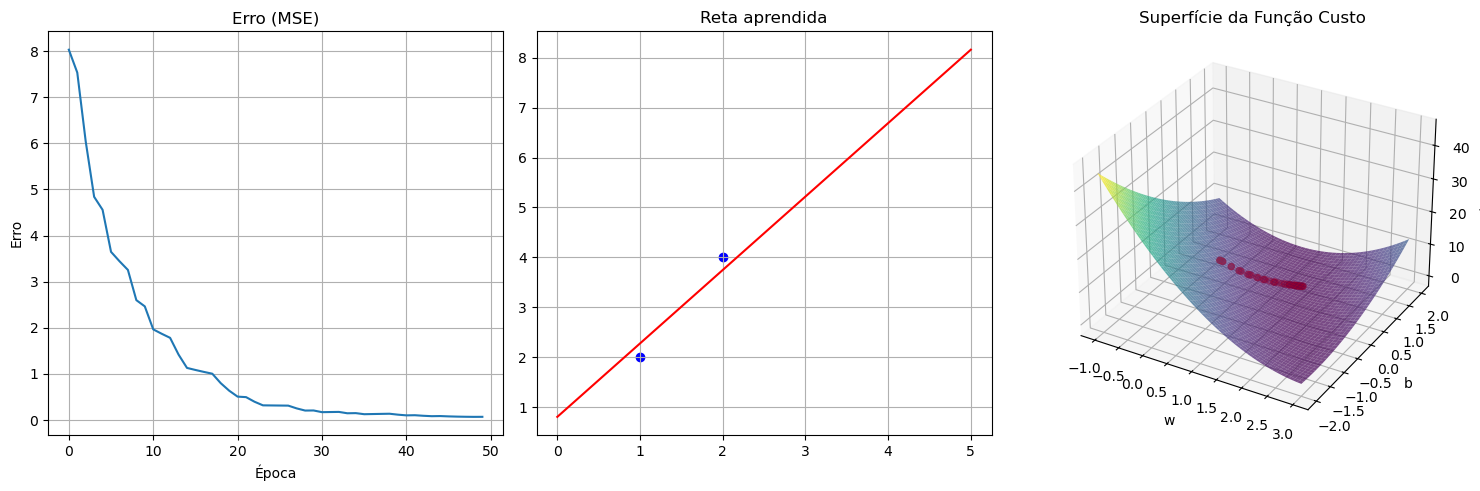

w final: 1.4697610546512883
b final: 0.8093094329068651


In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Dados
# -----------------------------
X = np.array([1, 2 ])
Y = np.array([2, 4])

# -----------------------------
# Parâmetros iniciais
# -----------------------------
w = 0.0
b = 0.0
lr = 0.01
epochs = 50

w_history = []
b_history = []
loss_history = []

# -----------------------------
# Função custo
# -----------------------------
def cost(w, b):
    return np.mean((w * X + b - Y) ** 2)

# -----------------------------
# Treinamento SGD
# -----------------------------
for epoch in range(epochs):
    i = random.randint(0, len(X) - 1)
    
    x = X[i]
    y = Y[i]
    
    y_pred = w * x + b
    error = y - y_pred
    
    dw = -2 * x * error
    db = -2 * error
    
    w = w - lr * dw
    b = b - lr * db
    
    w_history.append(w)
    b_history.append(b)
    loss_history.append(cost(w, b))

# -----------------------------
# Criando grade para superfície
# -----------------------------
w_vals = np.linspace(-1, 3, 50)
b_vals = np.linspace(-2, 2, 50)
W, B = np.meshgrid(w_vals, b_vals)
J = np.zeros_like(W)

for i in range(len(w_vals)):
    for j in range(len(b_vals)):
        J[j, i] = cost(W[j, i], B[j, i])

# -----------------------------
# Gráficos
# -----------------------------
fig = plt.figure(figsize=(15,5))

# 1️⃣ Erro ao longo do tempo
plt.subplot(1,3,1)
plt.plot(loss_history)
plt.title("Erro (MSE)")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.grid(True)

# 2️⃣ Ajuste final
plt.subplot(1,3,2)
plt.scatter(X, Y, color="blue")
x_line = np.linspace(0,5,100)
plt.plot(x_line, w*x_line + b, color="red")
plt.title("Reta aprendida")
plt.grid(True)

# 3️⃣ Superfície da função custo
ax = fig.add_subplot(1,3,3, projection='3d')
ax.plot_surface(W, B, J, cmap='viridis', alpha=0.7)

# trajetória do SGD
ax.scatter(w_history, b_history, loss_history, color='red')

ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w,b)")
ax.set_title("Superfície da Função Custo")

plt.tight_layout()
plt.show()

print("w final:", w)
print("b final:", b)
